# Day 56 - TensorFlow Data API: Shuffle, Prefetch & Keras- `tf.data.Dataset`
- `from_tensor_slices()`
- `map()`, `batch()`, `repeat()`, `shuffle()`
- `take()` and `skip()`
- Dataset transformation pipelines
- Shuffling and shuffle buffers
- Parallel preprocessing
- `prefetch()` and `tf.data.AUTOTUNE`
- Building train/validation/test pipelines
- Using `tf.data.Dataset` directly with `tf.keras.Model.fit()`
- Practical performance considerations

In [43]:
# Optional: install TensorFlow if it is not already installed.
# In your existing ml_env/tf_env environment, you normally do NOT need to run this.
# %pip install tensorflow

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 1. What is the TensorFlow Data API?

The `tf.data` API provides an efficient way to build input pipelines.

A dataset represents a sequence of elements:

```text
Dataset
  ↓
transform
  ↓
transform
  ↓
transform
  ↓
batches
  ↓
model
```

The major transformations we will use are:

| Transformation | Purpose |
|---|---|
| `shuffle()` | Randomize examples |
| `map()` | Transform/preprocess examples |
| `batch()` | Group examples into batches |
| `repeat()` | Repeat the dataset |
| `take()` | Take a limited number of elements |
| `skip()` | Skip elements |
| `prefetch()` | Prepare future batches asynchronously |



In [44]:
# 2. Creating a Dataset from tensors

X = np.arange(20)
y = X * 2

dataset = tf.data.Dataset.from_tensor_slices((X, y))

for x, target in dataset.take(5):
    print("x =", x.numpy(), "y =", target.numpy())


x = 0 y = 0
x = 1 y = 2
x = 2 y = 4
x = 3 y = 6
x = 4 y = 8


### `from_tensor_slices()`

If we have:

```python
X.shape = (1000, 10)
y.shape = (1000,)
```

then:

```python
tf.data.Dataset.from_tensor_slices((X, y))
```

creates a dataset containing **1000 `(X, y)` examples**.

This is useful when the data is already available in memory.


In [45]:
# 3. Dataset elements and shapes

X = np.random.rand(8, 4).astype(np.float32)
y = np.arange(8).astype(np.float32)

dataset = tf.data.Dataset.from_tensor_slices((X, y))

print("Element specification:")
print(dataset.element_spec)

for features, target in dataset.take(2):
    print("\nFeatures:", features.numpy())
    print("Target:", target.numpy())


Element specification:
(TensorSpec(shape=(4,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))

Features: [0.07693597 0.23451939 0.66807944 0.8654816 ]
Target: 0.0

Features: [0.93048674 0.49914965 0.01978695 0.6116703 ]
Target: 1.0


## 4. `map()` — transforming every example

`map()` applies a function to every element.

For example, suppose our feature values are between 0 and 100. We can scale them to approximately 0–1:

```python
dataset = dataset.map(lambda x, y: (x / 100.0, y))
```

For expensive preprocessing, use:

```python
num_parallel_calls=tf.data.AUTOTUNE
```

so TensorFlow can parallelize the work.


In [46]:
# 4. Using map() for preprocessing

features = np.arange(20, dtype=np.float32).reshape(10, 2)
targets = np.arange(10, dtype=np.float32)

dataset = tf.data.Dataset.from_tensor_slices((features, targets))

def preprocess(x, y):
    x = x / 20.0
    return x, y

processed_dataset = dataset.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

for x, y in processed_dataset.take(3):
    print("x:", x.numpy(), "y:", y.numpy())


x: [0.   0.05] y: 0.0
x: [0.1  0.15] y: 1.0
x: [0.2  0.25] y: 2.0


## 5. `batch()` — grouping examples

Instead of sending one example at a time to a model:

```text
example
example
example
...
```

we normally train using mini-batches:

```text
batch 1 → 32 examples
batch 2 → 32 examples
batch 3 → 32 examples
```

Example:

```python
dataset.batch(4)
```


In [47]:
# 5. Batching

dataset = tf.data.Dataset.from_tensor_slices(tf.range(12))

batched = dataset.batch(4)

for batch in batched:
    print(batch.numpy())


[0 1 2 3]
[4 5 6 7]
[ 8  9 10 11]


## 6. `shuffle()` — randomizing training examples

Shuffling helps prevent the model from learning unwanted ordering patterns.

A shuffle buffer is maintained internally:

```python
dataset.shuffle(buffer_size=1000)
```

Larger buffers generally provide better randomization, but require more memory.

For training datasets, a common pattern is:

```python
train_dataset = train_dataset.shuffle(
    buffer_size=10_000,
    reshuffle_each_iteration=True
)
```


In [48]:
# 6. Compare ordered vs shuffled datasets

dataset = tf.data.Dataset.from_tensor_slices(tf.range(20))

print("Original:")
print(list(dataset.as_numpy_iterator()))

shuffled = dataset.shuffle(
    buffer_size=20,
    reshuffle_each_iteration=False
)

print("\nShuffled:")
print(list(shuffled.as_numpy_iterator()))


Original:
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19)]

Shuffled:
[np.int32(3), np.int32(11), np.int32(12), np.int32(8), np.int32(6), np.int32(15), np.int32(2), np.int32(19), np.int32(4), np.int32(14), np.int32(18), np.int32(9), np.int32(5), np.int32(13), np.int32(16), np.int32(10), np.int32(0), np.int32(1), np.int32(17), np.int32(7)]


In [49]:
# 7. Observe reshuffling between iterations

dataset = tf.data.Dataset.from_tensor_slices(tf.range(10))

shuffled = dataset.shuffle(
    buffer_size=10,
    reshuffle_each_iteration=True
)

print("First iteration:")
print(list(shuffled.as_numpy_iterator()))

print("\nSecond iteration:")
print(list(shuffled.as_numpy_iterator()))


First iteration:
[np.int32(5), np.int32(6), np.int32(3), np.int32(8), np.int32(4), np.int32(2), np.int32(0), np.int32(7), np.int32(1), np.int32(9)]

Second iteration:
[np.int32(3), np.int32(0), np.int32(7), np.int32(6), np.int32(2), np.int32(5), np.int32(9), np.int32(4), np.int32(1), np.int32(8)]


## 7. `repeat()` — repeating a dataset

By default, a dataset is finite.

```python
dataset.repeat(3)
```

creates three copies of the dataset.

```python
dataset.repeat()
```

creates an indefinitely repeating dataset.

### Important

If you use an infinite dataset with `model.fit()`, specify `steps_per_epoch` so Keras knows how many batches form an epoch.


In [50]:
# 8. repeat()

dataset = tf.data.Dataset.from_tensor_slices(tf.range(5))

repeated = dataset.repeat(2)

print(list(repeated.as_numpy_iterator()))


[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


## 8. `take()` and `skip()`

These are useful for inspecting and splitting datasets.

```python
dataset.take(10)
```

takes the first 10 elements.

```python
dataset.skip(10)
```

skips the first 10 elements.

They can also be combined:

```python
validation = dataset.take(100)
training = dataset.skip(100)
```


In [51]:
# 9. take() and skip()

dataset = tf.data.Dataset.from_tensor_slices(tf.range(10))

first_three = dataset.take(3)
after_three = dataset.skip(3)

print("First 3:", list(first_three.as_numpy_iterator()))
print("After 3:", list(after_three.as_numpy_iterator()))


First 3: [np.int32(0), np.int32(1), np.int32(2)]
After 3: [np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)]


## 9. The complete pipeline

A typical training pipeline looks like:

```python
train_dataset = (
    train_dataset
    .shuffle(10_000)
    .map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
```

### Why this order?

- **Shuffle:** randomize training examples.
- **Map:** preprocess examples.
- **Batch:** combine examples into mini-batches.
- **Prefetch:** prepare future batches while the model trains.


In [52]:
# 10. Build a complete pipeline

X = np.random.rand(100, 4).astype(np.float32)
y = (X.sum(axis=1) > 2).astype(np.float32)

train_dataset = tf.data.Dataset.from_tensor_slices((X, y))

def preprocess_features(x, y):
    # Example preprocessing
    x = tf.cast(x, tf.float32)
    return x, y

train_dataset = (
    train_dataset
    .shuffle(buffer_size=100)
    .map(preprocess_features, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

for batch_x, batch_y in train_dataset.take(1):
    print("Batch X shape:", batch_x.shape)
    print("Batch y shape:", batch_y.shape)


Batch X shape: (16, 4)
Batch y shape: (16,)


## 10. Why `prefetch()` matters

Without prefetching:

```text
Prepare batch 1 → Train batch 1
Prepare batch 2 → Train batch 2
Prepare batch 3 → Train batch 3
```

The training step may have to wait for input preparation.

With prefetching:

```text
CPU:  Prepare batch 2 → Prepare batch 3 → Prepare batch 4
GPU:       Train batch 1 → Train batch 2 → Train batch 3
```

The two activities can overlap.

The recommended modern form is:

```python
.prefetch(tf.data.AUTOTUNE)
```

TensorFlow chooses a suitable prefetch amount automatically.


## 11. Parallel `map()`

Preprocessing can also be parallelized:

```python
dataset.map(
    preprocess_fn,
    num_parallel_calls=tf.data.AUTOTUNE
)
```

This is particularly useful when preprocessing is computationally expensive.

### Important distinction

```text
num_parallel_calls
        ↓
parallel preprocessing

prefetch
        ↓
overlap input preparation with model execution
```

They solve related but different pipeline-performance problems.


In [53]:
# 11. Parallel map + prefetch

def expensive_style_preprocess(x, y):
    # Simulate a simple TensorFlow preprocessing operation
    x = tf.math.sqrt(tf.abs(x) + 1e-6)
    return x, y

dataset = tf.data.Dataset.from_tensor_slices(
    (
        np.random.rand(1000, 4).astype(np.float32),
        np.random.randint(0, 2, size=1000).astype(np.float32)
    )
)

dataset = (
    dataset
    .shuffle(1000)
    .map(
        expensive_style_preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

print(dataset.element_spec)


(TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


## 12. Train/validation split with `tf.data`

One simple approach is to split NumPy arrays first and then create datasets.

This is often easier to understand while learning:

```text
X_train, y_train
X_valid, y_valid
X_test, y_test
        ↓
Dataset objects
        ↓
Pipeline transformations
```

For very large datasets, TensorFlow input pipelines can be built directly from files and other streaming sources.


In [54]:
# 12. Prepare a small binary classification dataset

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=2000,
    noise=0.20,
    random_state=42
)

X = X.astype(np.float32)
y = y.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (1400, 2) (1400,)
Valid: (300, 2) (300,)
Test : (300, 2) (300,)


In [55]:
# 13. Build train/validation/test datasets

BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
valid_ds = tf.data.Dataset.from_tensor_slices((X_valid, y_valid))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .shuffle(len(X_train))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

valid_ds = (
    valid_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipeline ready.")


Pipeline ready.


## 13. Using a Dataset with Keras

Keras can consume a `tf.data.Dataset` directly:

```python
model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=...
)
```

Keras receives batches from the dataset instead of receiving raw arrays directly.


In [56]:
# 14. Train a Keras model using tf.data

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    verbose=1
)


Epoch 1/10


c:\Users\Puneeth\anaconda3\envs\tf_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5936 - loss: 0.6717 - val_accuracy: 0.7800 - val_loss: 0.6234
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7929 - loss: 0.5823 - val_accuracy: 0.7967 - val_loss: 0.5313
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8100 - loss: 0.4923 - val_accuracy: 0.8267 - val_loss: 0.4425
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8307 - loss: 0.4155 - val_accuracy: 0.8400 - val_loss: 0.3779
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8486 - loss: 0.3620 - val_accuracy: 0.8633 - val_loss: 0.3360
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8586 - loss: 0.3273 - val_accuracy: 0.8767 - val_loss: 0.3081
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8629 - loss: 0.3049 - val_accuracy: 0.8733 - val_loss: 0.2903
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8700 - loss: 0.2902 - val_accuracy: 0.8800 - val_loss: 0.2784
Epo

In [57]:
# 15. Evaluate on the test dataset

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


Test loss: 0.236287459731102
Test accuracy: 0.8866666555404663


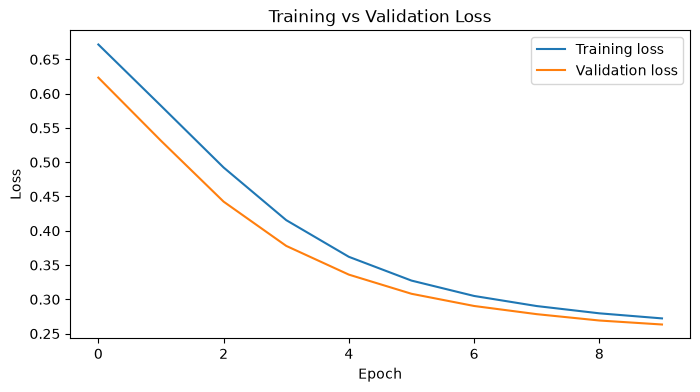

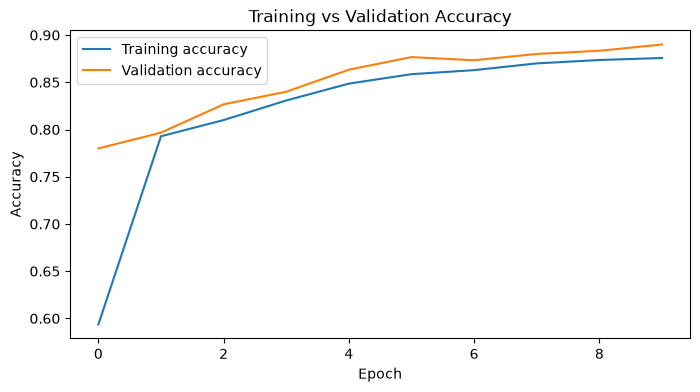

In [58]:
# 16. Visualize training history

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


## 14. `cache()` — useful additional optimization

`cache()` can avoid repeating expensive preprocessing.

For example:

```python
dataset = dataset.cache()
```

If the dataset fits in memory, subsequent epochs can reuse the cached results.

For a file:

```python
dataset = dataset.cache("cache_file")
```

### Be careful

Caching an enormous dataset in memory can consume a lot of RAM.

For today's core lesson, remember:

```text
cache()   → avoid repeating expensive input work
prefetch → overlap input preparation and model execution
```


In [59]:
# 17. cache() example

small_ds = tf.data.Dataset.from_tensor_slices(tf.range(10))

cached_ds = (
    small_ds
    .map(lambda x: x * x)
    .cache()
    .batch(5)
    .prefetch(tf.data.AUTOTUNE)
)

for batch in cached_ds:
    print(batch.numpy())


[ 0  1  4  9 16]
[25 36 49 64 81]


## 15. A production-style template

Use this as a reference when building TensorFlow projects:

```python
def preprocess(x, y):
    # Decode / resize / normalize / augment / etc.
    return x, y

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=len(X_train))
    .map(
        preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

valid_ds = (
    tf.data.Dataset.from_tensor_slices((X_valid, y_valid))
    .map(
        preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10
)
```


# 16. Mini Exercise — Build the pipeline yourself

Create a dataset with:

- 1000 samples
- 10 numerical features
- Binary labels
- Batch size = 32

Then create this pipeline:

```text
from_tensor_slices
       ↓
shuffle
       ↓
map
       ↓
batch
       ↓
prefetch
```

### Your task

1. Generate the data.
2. Create the dataset.
3. Write a preprocessing function that standardizes each feature.
4. Add shuffling.
5. Batch the data.
6. Add `prefetch(tf.data.AUTOTUNE)`.
7. Train a small Keras classifier using the resulting dataset.

Try it yourself before looking at the solution below.


In [60]:
# 17. Mini Exercise — Solution

X = np.random.randn(1000, 10).astype(np.float32)
y = (X[:, 0] + X[:, 1] > 0).astype(np.float32)

dataset = tf.data.Dataset.from_tensor_slices((X, y))

# Calculate statistics from the training data.
mean = X.mean(axis=0).astype(np.float32)
std = X.std(axis=0).astype(np.float32) + 1e-7

def standardize(x, y):
    x = (x - mean) / std
    return x, y

dataset = (
    dataset
    .shuffle(1000)
    .map(standardize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

exercise_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

exercise_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

exercise_model.fit(dataset, epochs=5)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6270 - loss: 0.6635
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7910 - loss: 0.5553
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8700 - loss: 0.4540
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9180 - loss: 0.3562
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9350 - loss: 0.2767


# 17. Common mistakes

### Mistake 1 — Forgetting to batch

```python
dataset = dataset.shuffle(1000)
```

This still gives individual examples.

For mini-batch training:

```python
dataset = dataset.batch(32)
```

### Mistake 2 — Forgetting prefetch

A correct pipeline can still be inefficient.

Use:

```python
.prefetch(tf.data.AUTOTUNE)
```

### Mistake 3 — Shuffling validation/test data unnecessarily

Training data is normally shuffled.

Validation and test data generally do not need random shuffling.

### Mistake 4 — Infinite `repeat()` without `steps_per_epoch`

This can cause training to continue indefinitely.

### Mistake 5 — Using an enormous shuffle buffer without considering memory

The buffer consumes resources. Choose an appropriate size.


# 18. Quick Sheet — Day 56

## Core API

```python
tf.data.Dataset.from_tensor_slices(data)
```

Creates a dataset.

```python
dataset.shuffle(1000)
```

Randomizes examples using a buffer.

```python
dataset.map(fn)
```

Transforms each example.

```python
dataset.batch(32)
```

Creates batches of 32.

```python
dataset.repeat()
```

Repeats indefinitely.

```python
dataset.take(10)
```

Takes 10 elements.

```python
dataset.skip(10)
```

Skips 10 elements.

```python
dataset.prefetch(tf.data.AUTOTUNE)
```

Overlaps input preparation with model execution.

## Best-practice training pipeline

```python
train_ds = (
    train_ds
    .shuffle(10_000)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
```

## Memory hook

```text
SHUFFLE → randomize
MAP     → transform
BATCH   → group
REPEAT  → repeat
PREFETCH→ prepare ahead
CACHE   → reuse
```
